In [3]:
import pandas as pd
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

df = pd.read_csv("Students Social Media Addiction.csv")

print(df.head())
print(df.shape)

   Student_ID  Age  Gender Academic_Level     Country  Avg_Daily_Usage_Hours  \
0           1   19  Female  Undergraduate  Bangladesh                    5.2   
1           2   22    Male       Graduate       India                    2.1   
2           3   20  Female  Undergraduate         USA                    6.0   
3           4   18    Male    High School          UK                    3.0   
4           5   21    Male       Graduate      Canada                    4.5   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0          Instagram                          Yes                    6.5   
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Soc

In [4]:
def addiction_level(score):
    if score <= 4:
        return "Low"
    elif score <= 7:
        return "Medium"
    else:
        return "High"

df["Addiction_Level"] = df["Addicted_Score"].apply(addiction_level)

print(df["Addiction_Level"].value_counts())

Addiction_Level
Medium    406
High      199
Low       100
Name: count, dtype: int64


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print(df.head())

   Student_ID  Age  Gender  Academic_Level  Country  Avg_Daily_Usage_Hours  \
0           1   19       0               2       10                    5.2   
1           2   22       1               0       39                    2.1   
2           3   20       0               2      102                    6.0   
3           4   18       1               1      101                    3.0   
4           5   21       1               0       18                    4.5   

   Most_Used_Platform  Affects_Academic_Performance  Sleep_Hours_Per_Night  \
0                   1                             1                    6.5   
1                   7                             0                    7.5   
2                   6                             1                    5.0   
3                  11                             0                    7.0   
4                   0                             1                    6.0   

   Mental_Health_Score  Relationship_Status  Conflicts_Over_So

In [6]:
X = df.drop(
    ["Student_ID", "Addicted_Score", "Addiction_Level"],
    axis=1
)

y = df["Addiction_Level"]

print(X.shape)
print(y.shape)

(705, 11)
(705,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (564, 11)
Testing: (141, 11)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Trained")

Logistic Regression Trained


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Trained")

Random Forest Trained


In [11]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

for name, pred in [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred)
]:

    print("\n", name)

    print("Accuracy:",
          accuracy_score(y_test, pred))

    print("Precision:",
          precision_score(y_test, pred,
                          average="weighted"))

    print("Recall:",
          recall_score(y_test, pred,
                       average="weighted"))

    print("F1 Score:",
          f1_score(y_test, pred,
                   average="weighted"))


 Logistic Regression
Accuracy: 0.9858156028368794
Precision: 0.9861573955396054
Recall: 0.9858156028368794
F1 Score: 0.9857662801078487

 Random Forest
Accuracy: 0.9858156028368794
Precision: 0.9861573955396054
Recall: 0.9858156028368794
F1 Score: 0.9855288194539281


In [12]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores")
print(scores)

print("Average Score")
print(scores.mean())

Cross Validation Scores
[0.90780142 0.93617021 0.97163121 1.         0.93617021]
Average Score
0.950354609929078


In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

rf_probs = rf.predict_proba(X_test)

y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

roc_auc = roc_auc_score(
    y_test_bin,
    rf_probs,
    multi_class="ovr"
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.99769751385913


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["High","Low","Medium"]
))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        40
         Low       1.00      0.90      0.95        20
      Medium       0.98      1.00      0.99        81

    accuracy                           0.99       141
   macro avg       0.99      0.97      0.98       141
weighted avg       0.99      0.99      0.99       141



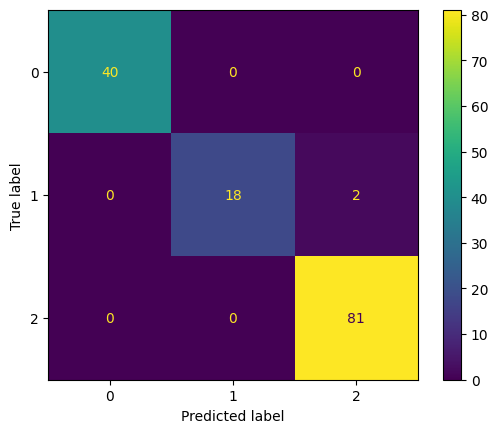

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()